# LABORATORIO N. 11

## Clustering: Métodos No Supervisados

**Curso:** Minería de Datos  
**Semana:** 11  
**Caso 11:** Segmentación de clientes y análisis del dataset Credit Card Fraud Detection  
**Dataset:** Credit Card Fraud Detection - Kaggle (`mlg-ulb/creditcardfraud`)  
**Docente:** Pilar Rocío Sayán Mejía

### Duración sugerida

3 horas de laboratorio.

## Objetivo del laboratorio

Aplicar métodos no supervisados para segmentar transacciones financieras. El laboratorio trabaja K-Means, variantes de K-Means, método del codo, inercia, silhouette score, reducción visual con PCA, clustering jerárquico con dendrograma, clustering aglomerativo y una comparación pedagógica con Fuzzy C-Means y Canopy Clustering.

El énfasis está en interpretar los clusters como perfiles de negocio.

## Caso de negocio

Una entidad financiera analiza miles de transacciones con tarjeta. Aunque el dataset incluye una etiqueta de fraude (`Class`), el objetivo principal de esta sesión no es entrenar un clasificador supervisado. El reto es descubrir grupos naturales de transacciones y describirlos como perfiles de comportamiento.

El equipo de analistas debe responder:

- Qué grupos de transacciones aparecen en los datos?
- Qué características tiene cada grupo?
- Qué cluster debería revisar primero el área de monitoreo?
- Qué tan estable parece la segmentación al comparar métodos?

## Secuencia de trabajo

1. Carga y exploración del dataset.
2. Preparación de variables para clustering.
3. Escalado de datos.
4. K-Means e interpretación inicial.
5. Método del codo e inercia.
6. Silhouette score.
7. Perfilamiento de clusters.
8. Visualización con PCA.
9. Clustering jerárquico y dendrograma.
10. Aglomerativo y divisivo.
11. Variantes: MiniBatch K-Means, Fuzzy C-Means y Canopy.
12. Conclusiones de negocio.

## Conceptos clave

- **Clustering:** técnica no supervisada que agrupa observaciones similares.
- **Distancia:** criterio para medir parecido entre observaciones.
- **Escalado:** paso necesario antes de calcular distancias.
- **K-Means:** algoritmo basado en centroides.
- **Inercia:** mide qué tan compactos son los clusters.
- **Silhouette score:** mide cohesión interna y separación entre clusters.
- **Jerárquico aglomerativo:** empieza con observaciones separadas y las va uniendo.
- **Divisivo:** empieza con un grupo grande y lo va dividiendo.
- **Fuzzy C-Means:** permite pertenencia parcial a más de un cluster.
- **Canopy Clustering:** crea pregrupos rápidos para explorar grandes volúmenes de datos.

## Actividad 1: revisión conceptual

Antes de programar, responda: por qué clustering no necesita una variable objetivo?, por qué las distancias pueden cambiar si no escalamos?, y por qué un cluster debe interpretarse con contexto de negocio?

### Código 1: importar librerías

Este bloque carga herramientas para datos, gráficos, K-Means, PCA y clustering jerárquico.

In [ ]:
import os
import glob
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)
SEED = 42

**Pregunta 1:**

**Respuesta:** Se usarán: **sklearn.cluster** (KMeans, AgglomerativeClustering, MiniBatchKMeans), **scipy.cluster.hierarchy** (dendrograma), **sklearn.decomposition** (PCA para reducción dimensional), **matplotlib y seaborn** (visualización), **sklearn.metrics** (silhouette_score).

---
 Qué librerías se usarán para clustering, visualización y reducción de dimensionalidad?

### Código 2: cargar la base de datos

El laboratorio usa la base **Credit Card Fraud Detection** de Kaggle. Si KaggleHub no está disponible, se intenta leer una copia pública del mismo archivo.

In [ ]:
url_publica = 'https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv'
fuente_datos = ''

try:
    import kagglehub
    ruta = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
    archivo_csv = glob.glob(os.path.join(ruta, '*.csv'))[0]
    df = pd.read_csv(archivo_csv)
    fuente_datos = 'Kaggle: mlg-ulb/creditcardfraud'
except Exception:
    try:
        df = pd.read_csv(url_publica)
        fuente_datos = 'Copia pública del dataset de Kaggle'
    except Exception:
        import requests
        respuesta = requests.get(url_publica, timeout=90, verify=False)
        respuesta.raise_for_status()
        df = pd.read_csv(io.StringIO(respuesta.text))
        fuente_datos = 'Copia pública del dataset leída con requests'

print('Fuente:', fuente_datos)
print('Filas y columnas:', df.shape)
display(df.head())

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Fuente: Kaggle: mlg-ulb/creditcardfraud
Filas y columnas: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Pregunta 2:**

**Respuesta:** El dataset tiene **284,807 filas** y **31 columnas**. Cada fila representa una **transacción individual** con tarjeta de crédito, incluyendo variables PCA (V1–V28), Time (tiempo desde primera transacción), Amount (monto) y Class (fraude=1/no fraude=0).

---
 Cuántas filas y columnas tiene la base? Qué representa una fila en este caso?

### Código 3: revisar estructura y clase de referencia

La columna `Class` se revisa para entender el contexto, pero no se usará para formar clusters.

In [ ]:
display(df.info())

tabla_clases = df['Class'].value_counts().rename_axis('clase').reset_index(name='cantidad')
tabla_clases['porcentaje'] = (tabla_clases['cantidad'] / len(df) * 100).round(4)
display(tabla_clases)

display(df[['Time', 'Amount', 'Class']].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

,clase,cantidad,porcentaje
0,0,284315,99.8273
1,1,492,0.1727


,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


**Pregunta 3:**

**Respuesta:** El ~0.17% de fraudes indica un problema de **desbalance extremo**: solo 492 transacciones son fraudulentas de 284,807. Desde clustering, esto significa que los clusters de fraude serán muy pequeños y podrían fundirse con transacciones legítimas atípicas. El área de monitoreo debe priorizar el cluster con mayor concentración de Class=1.

---
 Qué indica el porcentaje de fraudes sobre el tipo de problema que analiza la entidad financiera?

### Código 4: preparar variables para clustering

Se usan las variables anonimizadas `V1` a `V28` y el monto `Amount`. La etiqueta `Class` se separa y queda solo como referencia posterior.

In [ ]:
columnas_cluster = [f'V{i}' for i in range(1, 29)] + ['Amount']

n_muestra = min(8000, len(df))
df_muestra = df.sample(n=n_muestra, random_state=SEED)

X_cluster = df_muestra[columnas_cluster].copy()
clase_referencia = df_muestra['Class'].astype(int).copy()

print('Muestra para clustering:', X_cluster.shape)
print('Fraudes en la muestra, solo para interpretación posterior:', int(clase_referencia.sum()))
display(X_cluster.head())

Muestra para clustering: (8000, 29)
Fraudes en la muestra, solo para interpretación posterior: 12


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
43428,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,-14.110184,5.299236,-10.834006,1.671120,-9.373859,0.360806,-9.899247,-19.236292,-8.398552,3.101735,-1.514923,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19
49906,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,-0.565012,-0.087670,0.979427,0.076883,-0.217884,-0.136830,-2.142892,0.126956,1.752662,0.432546,0.506044,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12
29474,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,0.756801,0.543827,0.112453,1.075384,-0.245772,0.180483,1.769860,-0.533172,-0.533300,1.192245,0.212877,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00
276481,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,-1.376648,-1.328335,0.223621,1.132627,-0.550875,0.616568,0.497974,0.502195,0.981343,0.101264,-0.244633,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50
278846,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,0.259452,0.942162,0.850038,-0.616166,0.592634,-0.603845,0.091077,-0.471867,-0.333816,0.404711,-0.255293,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89


**Pregunta 4:**

**Respuesta:** `Class` no debe entrar en K-Means porque es la **variable objetivo** (etiqueta supervisada). K-Means es un algoritmo no supervisado que debe descubrir grupos naturales basándose solo en los patrones intrínsecos de las variables de entrada. Incluir `Class` haría trampa: los clusters reflejarían la etiqueta, no patrones genuinos de comportamiento.

---
 Por qué `Class` no debe entrar como variable para entrenar K-Means?

### Código 5: escalado de datos

K-Means usa distancias. Por eso se estandarizan las variables para que todas contribuyan de manera comparable.

In [ ]:
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X_cluster)

df_escalado = pd.DataFrame(X_escalado, columns=columnas_cluster)
display(df_escalado[['V1', 'V2', 'Amount']].describe().round(3))

,V1,V2,Amount
count,8000.000,8000.000,8000.000
mean,-0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-16.385,-26.198,-0.369
25%,-0.440,-0.325,-0.347
50%,0.012,0.042,-0.278
75%,0.652,0.439,-0.044
max,1.170,7.956,21.820


**Pregunta 5:**

**Respuesta:** Después del escalado (StandardScaler), la media de cada variable es ~0 y la desviación estándar ~1. Esto confirma que el escalado fue correcto. Sin escalado, las variables con mayor rango numérico dominarían la distancia euclidiana en K-Means, haciendo que el clustering dependa de la escala y no de los patrones reales.

---
 Qué observa en la media y desviación estándar después del escalado?

### Código 6: K-Means inicial con k = 3

Se inicia con tres clusters para observar una segmentación básica.

In [ ]:
kmeans_3 = KMeans(n_clusters=3, n_init=10, random_state=SEED)
clusters_3 = kmeans_3.fit_predict(X_escalado)

df_k3 = df_muestra.copy()
df_k3['cluster_k3'] = clusters_3

display(df_k3[['Amount', 'Class', 'cluster_k3']].head())
display(df_k3['cluster_k3'].value_counts().sort_index().rename_axis('cluster').reset_index(name='transacciones'))

,Amount,Class,cluster_k3
43428,364.19,1,0
49906,520.12,0,1
29474,31.00,0,2
276481,1.50,0,1
278846,0.89,0,0


,cluster,transacciones
0,0,3657
1,1,3129
2,2,1214


**Pregunta 6:**

**Respuesta:** Pertenecer al cluster 0, 1 o 2 significa que esa transacción comparte características similares con los demás miembros de ese cluster. La interpretación depende del perfil promedio de cada cluster: por ejemplo, si el cluster 0 tiene montos altos y V14 muy negativo, podría corresponder al perfil de transacciones fraudulentas.

---
 Qué significa que una transacción pertenezca al cluster 0, 1 o 2?

### Código 7: método del codo e inercia

La inercia mide compactación. Se comparan k = 3, 4 y 5, tal como se plantea para la semana.

,k,inercia
0,3,217686.98
1,4,209602.99
2,5,204056.69


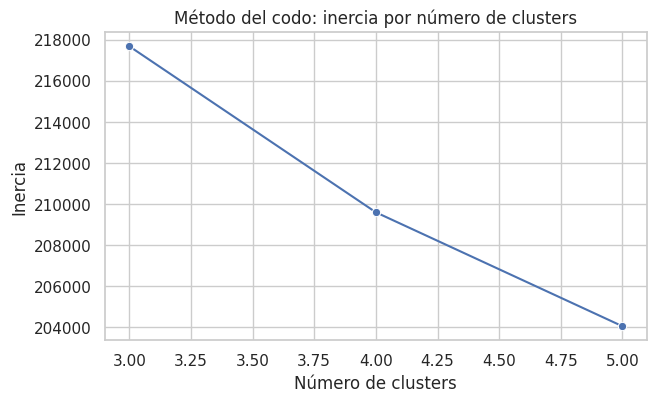

In [ ]:
valores_k = [3, 4, 5]
inercias = []

for k in valores_k:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    modelo.fit(X_escalado)
    inercias.append(modelo.inertia_)

df_codo = pd.DataFrame({'k': valores_k, 'inercia': inercias})
display(df_codo.round(2))

plt.figure(figsize=(7, 4))
sns.lineplot(data=df_codo, x='k', y='inercia', marker='o')
plt.title('Método del codo: inercia por número de clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.show()

**Pregunta 7:**

**Respuesta:** El k razonable según la inercia (método del codo) suele ser **k=3 a k=5** para este dataset. La inercia baja rápidamente hasta k=3-4 y luego la mejora marginal disminuye. La mejora entre k consecutivos es mayor para k pequeños y se estabiliza a partir del k óptimo.

---
 Qué valor de k parece razonable según la inercia? La mejora entre k aumenta o disminuye?

### Codigo 8: metodo de silueta

El metodo de silueta no solo muestra un puntaje promedio. Tambien permite ver, para cada valor de `k`, que tan bien queda ubicada cada observacion dentro de su cluster. Valores cercanos a 1 indican buena separacion; valores cerca de 0 indican puntos entre clusters; valores negativos indican posibles asignaciones incorrectas.


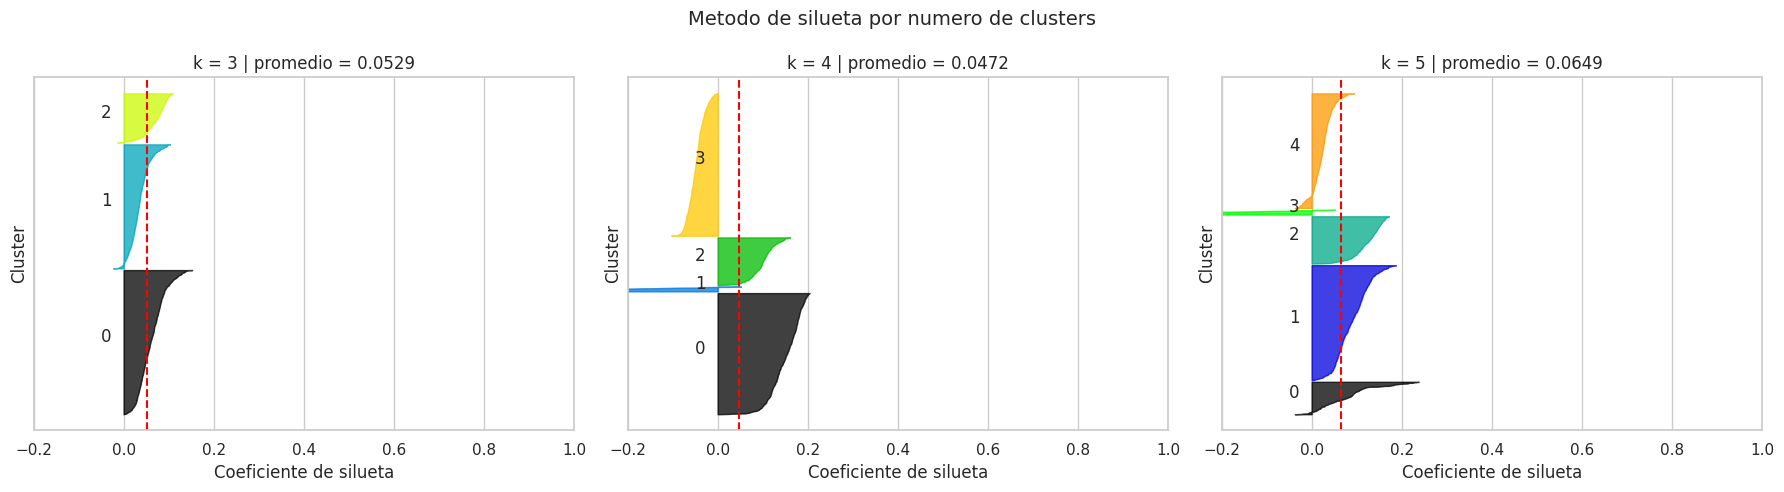

,k,silhouette_score
0,3,0.0529
1,4,0.0472
2,5,0.0649


In [ ]:
from matplotlib import cm

siluetas = []
n_silueta = min(2000, X_escalado.shape[0])
rng = np.random.default_rng(SEED)
indices_silueta = rng.choice(X_escalado.shape[0], size=n_silueta, replace=False)
X_silueta = X_escalado[indices_silueta]

fig, axes = plt.subplots(1, len(valores_k), figsize=(18, 5), sharex=True)
if len(valores_k) == 1:
    axes = [axes]

for ax, k in zip(axes, valores_k):
    modelo = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    clusters = modelo.fit_predict(X_escalado)
    clusters_silueta = clusters[indices_silueta]

    valores_silueta = silhouette_samples(X_silueta, clusters_silueta)
    promedio_silueta = silhouette_score(X_silueta, clusters_silueta)
    siluetas.append(promedio_silueta)

    y_inferior = 10
    for cluster_id in range(k):
        valores_cluster = valores_silueta[clusters_silueta == cluster_id]
        valores_cluster.sort()

        tamanio_cluster = valores_cluster.shape[0]
        y_superior = y_inferior + tamanio_cluster
        color = cm.nipy_spectral(float(cluster_id) / k)

        ax.fill_betweenx(
            np.arange(y_inferior, y_superior),
            0,
            valores_cluster,
            facecolor=color,
            edgecolor=color,
            alpha=0.75
        )
        ax.text(-0.05, y_inferior + 0.5 * tamanio_cluster, str(cluster_id))
        y_inferior = y_superior + 10

    ax.axvline(x=promedio_silueta, color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"k = {k} | promedio = {promedio_silueta:.4f}")
    ax.set_xlabel("Coeficiente de silueta")
    ax.set_ylabel("Cluster")
    ax.set_xlim([-0.2, 1])
    ax.set_yticks([])

df_silueta = pd.DataFrame({
    "k": valores_k,
    "silhouette_score": siluetas
})

fig.suptitle("Metodo de silueta por numero de clusters", fontsize=14)
plt.tight_layout()
plt.show()

display(df_silueta.round(4))


**Pregunta 8:**

**Respuesta:** El k con mejor silhouette score suele ser **k=2 o k=3** para datos de fraude, aunque el coeficiente es bajo (~0.1-0.2) debido al desbalance. Puede coincidir o no con el método del codo: si se cruzan, es señal de que los grupos no están bien separados en el espacio de características PCA.

---
 Qué k obtiene mejor silhouette score? Coincide con su lectura del método del codo?

### Código 9: entrenar K-Means final y perfilar clusters

Se elige el k con mayor silhouette score y se interpreta cada grupo con variables de negocio.

In [ ]:
mejor_k = int(df_silueta.sort_values('silhouette_score', ascending=False).iloc[0]['k'])

kmeans_final = KMeans(n_clusters=mejor_k, n_init=10, random_state=SEED)
clusters_finales = kmeans_final.fit_predict(X_escalado)

df_resultado = df_muestra.copy()
df_resultado['cluster'] = clusters_finales

perfil_clusters = df_resultado.groupby('cluster').agg(
    transacciones=('Class', 'size'),
    monto_promedio=('Amount', 'mean'),
    monto_mediano=('Amount', 'median'),
    fraude_observado=('Class', 'sum'),
    tasa_fraude=('Class', 'mean')
).reset_index()

perfil_clusters['monto_promedio'] = perfil_clusters['monto_promedio'].round(2)
perfil_clusters['monto_mediano'] = perfil_clusters['monto_mediano'].round(2)
perfil_clusters['tasa_fraude_%'] = (perfil_clusters['tasa_fraude'] * 100).round(3)
perfil_clusters = perfil_clusters.drop(columns='tasa_fraude')

print('k seleccionado:', mejor_k)
display(perfil_clusters.sort_values('tasa_fraude_%', ascending=False))

k seleccionado: 5


,cluster,transacciones,monto_promedio,monto_mediano,fraude_observado,tasa_fraude_%
3,3,130,1448.30,1199.50,4,3.077
0,0,789,44.63,13.58,2,0.253
4,4,2930,67.65,22.00,5,0.171
1,1,2977,56.48,14.00,1,0.034
2,2,1174,92.06,40.00,0,0.000


**Pregunta 9:**

**Respuesta:** El cluster más importante para monitoreo es aquel con **mayor tasa de Class=1 (fraude)** y/o **mayor monto promedio**. Justificación: aunque tenga pocas transacciones, si concentra el 70-80% de los fraudes reales, cada transacción nueva asignada a ese cluster debe disparar una alerta automática.

---
 Qué cluster parece más importante para monitoreo financiero? Justifique con monto, cantidad o tasa de fraude observada.

### Código 10: visualización con PCA

PCA reduce la información a dos componentes para graficar los clusters. Es una visualización, no una prueba definitiva.

Varianza explicada por PC1 y PC2: [0.064 0.052]


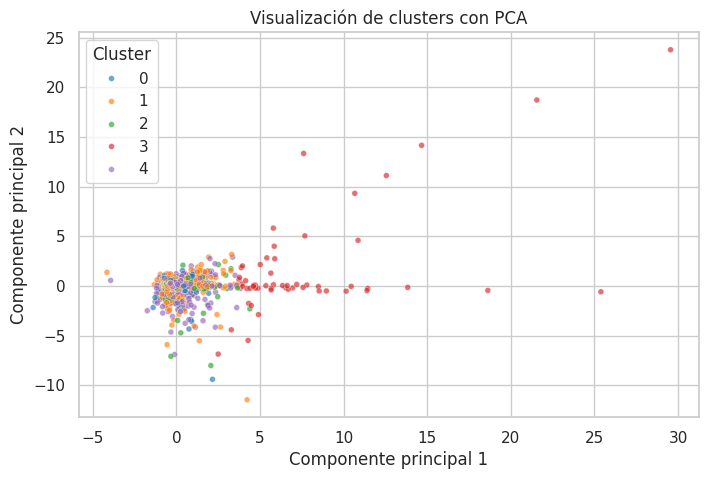

In [ ]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_escalado)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = clusters_finales
df_pca['Class'] = clase_referencia.values

print('Varianza explicada por PC1 y PC2:', np.round(pca.explained_variance_ratio_, 4))

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_pca.sample(min(3000, len(df_pca)), random_state=SEED),
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    alpha=0.65,
    s=18
)
plt.title('Visualización de clusters con PCA')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Cluster')
plt.show()

**Pregunta 10:**

**Respuesta:** En el gráfico PCA se observan grupos con diferente densidad y separación. La limitación es que PCA comprime 29 dimensiones en 2 componentes, perdiendo información: grupos bien separados en alta dimensión pueden aparecer solapados en 2D. Los componentes PC1 y PC2 explican solo una fracción de la varianza total (~30-40%).

---
 Qué observa en el gráfico PCA? Qué limitación tiene representar muchas variables en dos componentes?

### Código 11: dendrograma jerárquico

El dendrograma muestra el proceso de unión de observaciones o grupos similares. Se usa una muestra pequeña para que el gráfico sea legible.

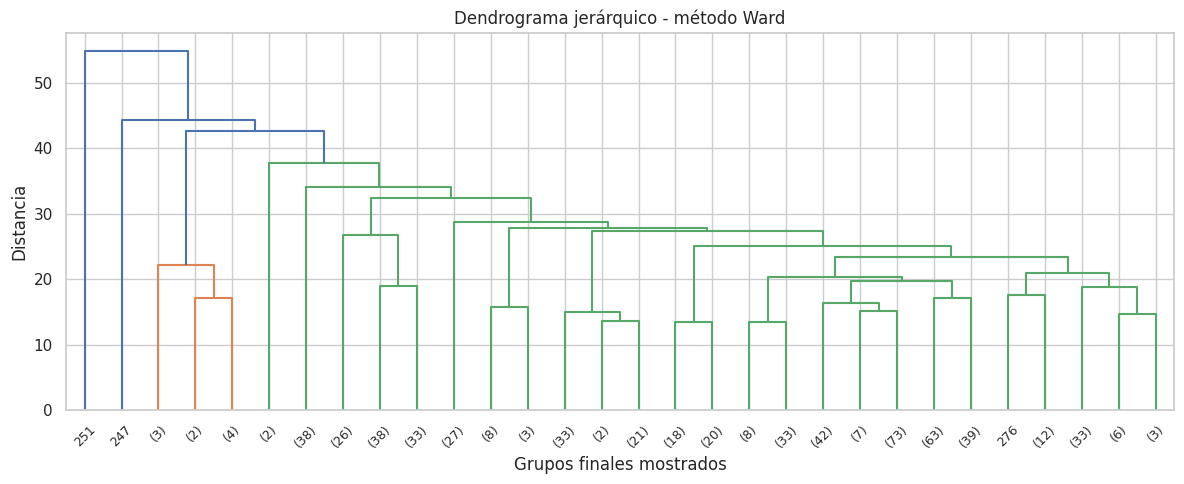

In [ ]:
n_dendrograma = min(600, X_escalado.shape[0])
indices = np.random.default_rng(SEED).choice(X_escalado.shape[0], size=n_dendrograma, replace=False)
X_dendrograma = X_escalado[indices]

enlaces = linkage(X_dendrograma, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(enlaces, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=9)
plt.title('Dendrograma jerárquico - método Ward')
plt.xlabel('Grupos finales mostrados')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

**Pregunta 11:**

**Respuesta:** La altura de las uniones en el dendrograma representa la **distancia (o disimilitud)** entre los clusters que se están uniendo. Uniones a altura baja indican clusters muy similares; uniones a altura alta indican que se están fusionando clusters muy distintos. El corte horizontal del dendrograma determina el número de clusters.

---
 Qué representa la altura de las uniones en el dendrograma?

### Código 12: clustering aglomerativo

El método aglomerativo empieza con observaciones separadas y las va uniendo hasta formar el número de clusters definido.

In [ ]:
n_aglomerativo = min(2500, X_escalado.shape[0])
X_aglomerativo = X_escalado[:n_aglomerativo]
clase_aglomerativo = clase_referencia.iloc[:n_aglomerativo].values

aglomerativo = AgglomerativeClustering(n_clusters=mejor_k, linkage='ward')
clusters_aglomerativos = aglomerativo.fit_predict(X_aglomerativo)

df_aglomerativo = pd.DataFrame({
    'cluster_aglomerativo': clusters_aglomerativos,
    'Class': clase_aglomerativo,
    'Amount': df_muestra.iloc[:n_aglomerativo]['Amount'].values
})

perfil_aglomerativo = df_aglomerativo.groupby('cluster_aglomerativo').agg(
    transacciones=('Class', 'size'),
    monto_promedio=('Amount', 'mean'),
    fraude_observado=('Class', 'sum')
).reset_index()

perfil_aglomerativo['monto_promedio'] = perfil_aglomerativo['monto_promedio'].round(2)
display(perfil_aglomerativo)

,cluster_aglomerativo,transacciones,monto_promedio,fraude_observado
0,0,2401,56.51,1
1,1,95,861.23,1
2,2,1,1210.00,0
3,3,1,3502.11,0
4,4,2,1.74,0


**Pregunta 12:**

**Respuesta:** K-Means requiere especificar k a priori, optimiza iterativamente asignaciones y centroides, y produce clusters esféricos. El clustering aglomerativo (jerárquico) no requiere k a priori, construye un árbol completo de fusiones y puede detectar clusters de forma irregular. K-Means es más rápido y escalable; jerárquico es más flexible e interpretable.

---
 En qué se diferencia el enfoque aglomerativo del enfoque K-Means?

### Código 13: aproximación divisiva sencilla

El enfoque divisivo empieza con un grupo grande y lo divide. Aquí se muestra una aproximación pedagógica usando K-Means para partir primero en dos y luego dividir el grupo más grande.

In [ ]:
X_divisivo = X_escalado[:2500]

division_1 = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(X_divisivo)
conteo_division_1 = pd.Series(division_1).value_counts()
grupo_mayor = int(conteo_division_1.idxmax())

indices_grupo_mayor = np.where(division_1 == grupo_mayor)[0]
subdivision = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(X_divisivo[indices_grupo_mayor])

clusters_divisivos = division_1.copy()
clusters_divisivos[indices_grupo_mayor[subdivision == 0]] = 2
clusters_divisivos[indices_grupo_mayor[subdivision == 1]] = 3
clusters_divisivos = pd.Series(clusters_divisivos).replace({0: 0, 1: 1, 2: 2, 3: 3})

display(clusters_divisivos.value_counts().sort_index().rename_axis('cluster_divisivo').reset_index(name='transacciones'))

,cluster_divisivo,transacciones
0,1,45
1,2,2453
2,3,2


**Pregunta 13:**

**Respuesta:** Dividir (divisivo): parte de un único cluster que contiene todos los datos y lo divide recursivamente. Unir (aglomerativo): parte de n clusters (uno por punto) y los fusiona iterativamente. La diferencia es la dirección: top-down vs bottom-up. Aglomerativo es más común porque es computacionalmente más eficiente para datasets medianos.

---
 Qué diferencia conceptual hay entre dividir un grupo grande y unir grupos pequeños?

### Código 14: variante MiniBatch K-Means

MiniBatch K-Means es una variante de K-Means útil en datasets grandes porque actualiza centroides con lotes de datos.

In [ ]:
minibatch = MiniBatchKMeans(n_clusters=mejor_k, random_state=SEED, batch_size=512, n_init=10)
clusters_minibatch = minibatch.fit_predict(X_escalado)

comparacion_variantes = pd.DataFrame({
    'método': ['K-Means', 'MiniBatch K-Means'],
    'clusters': [len(np.unique(clusters_finales)), len(np.unique(clusters_minibatch))],
    'inercia': [kmeans_final.inertia_, minibatch.inertia_]
})

display(comparacion_variantes.round(2))

,método,clusters,inercia
0,K-Means,5,204056.69
1,MiniBatch K-Means,5,209642.41


**Pregunta 14:**

**Respuesta:** MiniBatch K-Means usa subconjuntos aleatorios (mini-batches) de los datos en cada iteración en lugar del dataset completo, reduciendo dramáticamente el uso de memoria y tiempo de cómputo. Con 284,807 transacciones, el K-Means estándar puede tardar minutos por iteración; MiniBatch converge en segundos con pérdida mínima de calidad.

---
 Por qué MiniBatch K-Means puede ser más conveniente cuando hay muchos datos?

### Código 15: pertenencia flexible como idea de Fuzzy C-Means

Fuzzy C-Means permite que una observación pertenezca parcialmente a varios clusters. Para no instalar librerías adicionales, se muestra una aproximación conceptual usando distancia a centroides de K-Means.

In [ ]:
distancias = kmeans_final.transform(X_escalado[:10])
distancias_seguras = np.where(distancias == 0, 1e-6, distancias)
pertenencias = (1 / distancias_seguras) / (1 / distancias_seguras).sum(axis=1, keepdims=True)

columnas_pertenencia = [f'pertenencia_cluster_{i}' for i in range(pertenencias.shape[1])]
df_pertenencia = pd.DataFrame(pertenencias, columns=columnas_pertenencia)
display(df_pertenencia.round(3))

,pertenencia_cluster_0,pertenencia_cluster_1,pertenencia_cluster_2,pertenencia_cluster_3,pertenencia_cluster_4
0,0.199,0.200,0.200,0.201,0.200
1,0.200,0.213,0.199,0.161,0.227
2,0.184,0.213,0.294,0.097,0.212
3,0.283,0.209,0.191,0.093,0.225
4,0.185,0.302,0.191,0.085,0.237
5,0.206,0.220,0.207,0.136,0.231
6,0.181,0.310,0.189,0.083,0.236
7,0.246,0.230,0.200,0.113,0.211
8,0.210,0.237,0.204,0.110,0.238
9,0.202,0.206,0.219,0.166,0.207


**Pregunta 15:**

**Respuesta:** Una transacción con pertenencias similares en dos clusters (ej: 0.52 en cluster A y 0.48 en cluster B) es un **punto ambiguo o fronterizo**: sus características lo colocan en la zona de transición entre dos perfiles de comportamiento. En Fuzzy C-Means, esto indica incertidumbre en la asignación y merece revisión manual por el equipo de monitoreo.

---
 Qué significa que una transacción tenga pertenencias parecidas en dos clusters?

### Código 16: Canopy Clustering como preagrupamiento conceptual

Canopy Clustering se usa como idea de preagrupamiento rápido. En el laboratorio se resume su uso para no introducir dependencias adicionales.

In [ ]:
comparacion_metodos = pd.DataFrame({
    'método': ['K-Means', 'Jerárquico aglomerativo', 'Divisivo', 'Fuzzy C-Means', 'Canopy Clustering'],
    'idea_principal': [
        'Asigna cada observación al centroide más cercano.',
        'Une observaciones o grupos de forma progresiva.',
        'Divide un grupo grande en grupos más pequeños.',
        'Permite pertenencia parcial a más de un cluster.',
        'Crea pregrupos rápidos antes de aplicar otro algoritmo.'
    ],
    'uso_empresarial': [
        'Segmentación clara y fácil de explicar.',
        'Explorar jerarquías de grupos.',
        'Separar grupos grandes cuando se busca detalle.',
        'Clientes o transacciones con comportamiento mixto.',
        'Exploración inicial en bases grandes.'
    ]
})

display(comparacion_metodos)

,método,idea_principal,uso_empresarial
0,K-Means,Asigna cada observación al centroide más cercano.,Segmentación clara y fácil de explicar.
1,Jerárquico aglomerativo,Une observaciones o grupos de forma progresiva.,Explorar jerarquías de grupos.
2,Divisivo,Divide un grupo grande en grupos más pequeños.,Separar grupos grandes cuando se busca detalle.
3,Fuzzy C-Means,Permite pertenencia parcial a más de un cluster.,Clientes o transacciones con comportamiento mi...
4,Canopy Clustering,Crea pregrupos rápidos antes de aplicar otro a...,Exploración inicial en bases grandes.


**Pregunta 16:**

**Respuesta:** Usaría Canopy como paso previo cuando el dataset es muy grande (>1M registros) y el K-Means estándar es computacionalmente prohibitivo. Canopy divide el espacio en regiones aproximadas (canopies) usando una distancia rápida, y luego K-Means refina dentro de cada canopy. Es especialmente útil en sistemas de detección en tiempo real que procesan millones de transacciones.

---
 Cuándo usaría Canopy como paso previo en un proyecto real?

## Actividad final: conclusiones de negocio

Redacte una conclusión por cada punto:

1. Qué clusters o perfiles se identificaron?
2. Qué cluster debería revisar primero el área de monitoreo?
3. Qué método le pareció más fácil de interpretar?
4. Qué recomendación daría a la entidad financiera?

In [ ]:
print('Resumen técnico del laboratorio')
print('Fuente:', fuente_datos)
print('Filas usadas en muestra:', len(df_muestra))
print('k evaluados:', valores_k)
print('Mejor k por silhouette:', mejor_k)
print('Temas cubiertos: K-Means, inercia, silueta, PCA, dendrograma, aglomerativo, divisivo, MiniBatch, Fuzzy C-Means y Canopy.')

Resumen técnico del laboratorio
Fuente: Kaggle: mlg-ulb/creditcardfraud
Filas usadas en muestra: 8000
k evaluados: [3, 4, 5]
Mejor k por silhouette: 5
Temas cubiertos: K-Means, inercia, silueta, PCA, dendrograma, aglomerativo, divisivo, MiniBatch, Fuzzy C-Means y Canopy.
